# Localised state analysis — dividing a state into sections, 2023

Madhya Pradesh first, then Telangana.

Files: `peak_gcvi_kharif_2023_mp_raw_10m.tif`, `peak_gcvi_kharif_2023_mp_jordi_10m.tif`

1. Pooled correlation across districts, raw vs Jordi rice mask, with the district scatter
2. Pixel-wise peak GCVI over eastern MP, with 2023 district yields labelled

---

### Input checks

| check | result |
|---|---|
| grid | 3260 × 2155 px, 0.0026949° ≈ **299 m**, EPSG:4326 |
| nodata | not set — non-rice and out-of-AOI pixels stored as `0` |
| zeros | raw 46.4% of the bounding box, jordi 79.3% |
| pixels > 0 | raw 3,748,692 · jordi 1,453,556 (20.7% of raw) |
| jordi vs raw where jordi > 0 | differ in 96.4% of pixels, mean abs diff 0.55, max 434 |

Notes carried into the code:

1. **The files on disk are ~299 m, not 10 m.** The GEE asset is at 10 m, but
   `getDownloadURL` caps each dimension at 32768 px and MP is 97,777 × 64,621 at 10 m,
   so the download fell back to the coarser grid. Re-run with `Export.image.toDrive`
   to get the native resolution; only the paths in `TIF` need to change afterwards.
2. **`0` means no rice** (confirmed), so zeros are excluded from the district means
   rather than averaged in.
3. **The two rasters are not one composite plus a mask** — values differ where both are
   positive, so any difference in r below mixes the mask with whatever else differs
   between the two exports.

### Extraction matches the 500 m and 300 m analyses

District means are computed the same way as `extract_gcvi()` (500 m cache) and
`district_means()` (300 m nationwide):

    zonal_stats(polygons, array, stats=['mean','median','count'], nodata=np.nan)
    gcvi_mean = gcvi_mean.fillna(0)      # district with NO retained pixels -> 0 (KEEP)

One MP-specific step is required first: those exports store masked pixels as **NaN**,
while these files store them as **0**, so `0 -> NaN` is applied to put this raster on
the same footing. Negatives are kept and no outlier clip is applied, matching the other
two paths (statewide that leaves raw max 158, jordi max 454 in the pixel pool).

In [1]:
import os, re, glob, warnings
import numpy as np, pandas as pd, nbformat
import geopandas as gpd, rasterio
from rasterstats import zonal_stats
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy import stats
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 14, 'axes.titlesize': 17, 'axes.labelsize': 15,
    'xtick.labelsize': 13, 'ytick.labelsize': 13,
    'legend.fontsize': 13, 'legend.title_fontsize': 13, 'figure.titlesize': 20,
})

ROOT, OUT, YEAR = '..', '../outputs', 2023
STATE, SNAME = 'mp', 'Madhya Pradesh'
TIF = {'raw':   f'{ROOT}/data/gcvi/peak_gcvi_kharif_{YEAR}_{STATE}_raw_10m.tif',
       'jordi': f'{ROOT}/data/gcvi/peak_gcvi_kharif_{YEAR}_{STATE}_jordi_10m.tif'}
LABEL = {'raw': 'raw (no mask)', 'jordi': 'Jordi rice mask'}

_nb  = nbformat.read(f'{ROOT}/notebooks/02_mask_analysis/gsv_preds_exploration.ipynb', as_version=4)
_src = next(c.source for c in _nb.cells if c.get('id') == 'ee4f17d1')
_src = _src.replace("os.makedirs('outputs', exist_ok=True)", "").replace("'../../data/", f"'{ROOT}/data/")
CFG = {}; exec(_src, CFG)
REGIONS, load_yield = CFG['REGIONS'], CFG['load_yield']

G = gpd.read_file(REGIONS[STATE]['shp']).to_crs('EPSG:4326')
G = G[G.geometry.notna() & ~G.geometry.is_empty]
G['district'] = G['gaul2_name'].str.strip().str.title().str.replace(r'\s+', ' ', regex=True)

Y = load_yield(SNAME); Y = Y[Y.year == YEAR][['district', 'yield_kg_ha']]
print(f"{len(G)} district polygons · {len(Y)} districts with {YEAR} yield · "
      f"{len(set(G.district) & set(Y.district))} matched")

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Configured 30 states.


53 district polygons · 49 districts with 2023 yield · 49 matched


In [2]:
def to_nan_encoding(a):
    """These files store masked pixels as 0; the 500 m / 300 m exports store NaN.
    Convert so the same zonal statistics apply. Negatives are kept, as in those paths."""
    a = a.astype('float32')
    a[~np.isfinite(a)] = np.nan
    a[a == 0] = np.nan
    return a


def district_stats(tif_path):
    """Same call as extract_gcvi() / district_means(): zonal_stats, nodata=NaN,
    then fillna(0) for districts with no retained pixels (the KEEP convention)."""
    with rasterio.open(tif_path) as src:
        a   = to_nan_encoding(src.read(1))
        aff = src.transform
    st = zonal_stats(G, a, affine=aff, stats=['mean', 'median', 'count'], nodata=np.nan)
    return pd.DataFrame({'district':    G['district'].values,
                         'gcvi_mean':   [s['mean']   for s in st],
                         'gcvi_median': [s['median'] for s in st],
                         'n_px':        [s['count']  for s in st]})


D = None
for t, path in TIF.items():
    s = district_stats(path)
    n_empty = int((s.n_px == 0).sum())
    s['gcvi_mean'] = s['gcvi_mean'].fillna(0)          # KEEP, as in the other notebooks
    s = s.rename(columns={'gcvi_mean': f'gcvi_{t}', 'gcvi_median': f'med_{t}',
                          'n_px': f'npx_{t}'})
    D = s if D is None else D.merge(s, on='district', how='outer')
    print(f"  {t:<6} done   districts with no retained pixels: {n_empty}")

D = D.merge(Y, on='district', how='inner')
D['rice_px_frac'] = D.npx_jordi / D.npx_raw
D.to_csv(f'{OUT}/mp_highres_district_{YEAR}.csv', index=False)
print(f"\n{len(D)} districts with both GCVI and {YEAR} yield\n")
print(D[['district', 'gcvi_raw', 'gcvi_jordi', 'npx_raw', 'npx_jordi',
         'rice_px_frac', 'yield_kg_ha']].round(3).to_string(index=False))

  raw    done   districts with no retained pixels: 0


  jordi  done   districts with no retained pixels: 0

49 districts with both GCVI and 2023 yield

    district  gcvi_raw  gcvi_jordi  npx_raw  npx_jordi  rice_px_frac  yield_kg_ha
   Alirajpur     4.137       3.809    40218      15567         0.387       1441.0
     Anuppur     4.510       4.300    45740      34488         0.754       1486.0
  Ashoknagar     4.388       3.278    58130      10867         0.187       2167.0
    Balaghat     5.701       5.496   111317      94740         0.851       1837.0
     Barwani     3.611       2.920    65266       8783         0.135       1144.0
       Betul     4.413       3.906   120956      38851         0.321       1755.0
       Bhind     2.848       3.588    55605      25826         0.464       2578.0
      Bhopal     3.920       3.243    33677       9252         0.275       2185.0
   Burhanpur     3.701       3.193    38657      10137         0.262       1192.0
  Chhatarpur     4.201       3.385   106643      40725         0.382       1277.0


Pooled correlation across districts, Madhya Pradesh 2023
one Pearson over districts; n = number of districts

condition            n        r        p  signed R2     slope  sd_gcvi
----------------------------------------------------------------------
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
raw (no mask)       49   +0.170   0.2416     +0.029       182    0.473
Jordi rice mask     49   +0.533   0.0001     +0.284       358    0.750

Δr (jordi − raw) = +0.362
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
yield: mean 1787  sd 504  CV 0.282   range 787-2578
Intel MKL WARNING: Support 

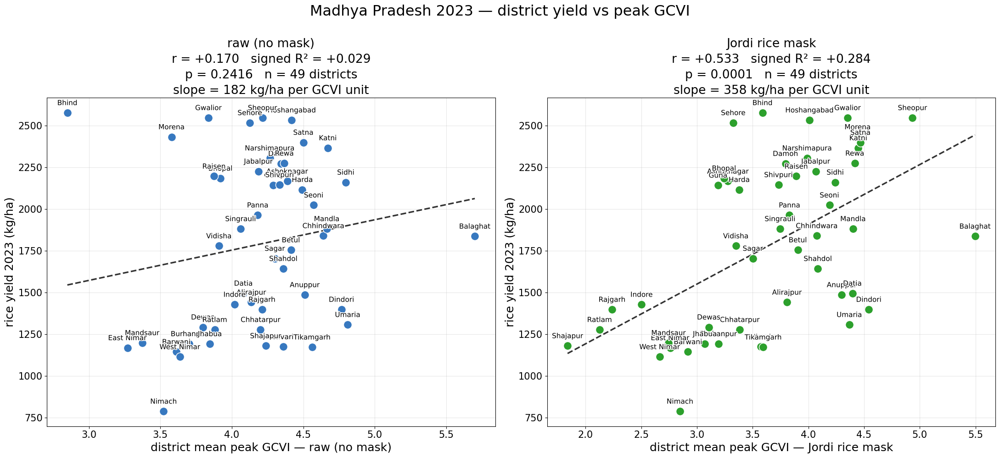

In [3]:
def sr2(r):
    """signed R^2 = sign(r) * r^2 — variance explained, keeping the direction."""
    return np.sign(r) * r**2


def pear(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 4:
        return np.nan, np.nan, int(m.sum())
    r = stats.pearsonr(x[m], y[m])
    return r.statistic, r.pvalue, int(m.sum())


print(f"Pooled correlation across districts, {SNAME} {YEAR}")
print("one Pearson over districts; n = number of districts\n")
print(f"{'condition':<18}{'n':>4}{'r':>9}{'p':>9}{'signed R2':>11}{'slope':>10}{'sd_gcvi':>9}")
print('-' * 70)
res = {}
for t in ['raw', 'jordi']:
    x, y = D[f'gcvi_{t}'].values, D.yield_kg_ha.values
    r, p, n = pear(x, y)
    m = np.isfinite(x) & np.isfinite(y)
    b = stats.linregress(x[m], y[m]).slope
    res[t] = dict(r=r, p=p, n=n, b=b)
    print(f"{LABEL[t]:<18}{n:>4}{r:>+9.3f}{p:>9.4f}{np.sign(r)*r**2:>+11.3f}{b:>10.0f}"
          f"{np.nanstd(x, ddof=1):>9.3f}")
print(f"\nΔr (jordi − raw) = {res['jordi']['r'] - res['raw']['r']:+.3f}")
print(f"yield: mean {D.yield_kg_ha.mean():.0f}  sd {D.yield_kg_ha.std():.0f}  "
      f"CV {D.yield_kg_ha.std()/D.yield_kg_ha.mean():.3f}   "
      f"range {D.yield_kg_ha.min():.0f}-{D.yield_kg_ha.max():.0f}")

fig, axes = plt.subplots(1, 2, figsize=(22, 10))
for ax, t in zip(axes, ['raw', 'jordi']):
    x, y = D[f'gcvi_{t}'], D.yield_kg_ha
    ax.scatter(x, y, s=170, color='#2ca02c' if t == 'jordi' else '#3778bf',
               edgecolors='white', linewidths=1.1, zorder=3)
    m = np.isfinite(x) & np.isfinite(y)
    lr = stats.linregress(x[m], y[m])
    xs = np.linspace(x[m].min(), x[m].max(), 50)
    ax.plot(xs, lr.intercept + lr.slope * xs, ls='--', lw=2.4, color='#333', zorder=2)
    for _, r in D.iterrows():
        if np.isfinite(r[f'gcvi_{t}']):
            ax.annotate(r.district, (r[f'gcvi_{t}'], r.yield_kg_ha), fontsize=11,
                        textcoords='offset points', xytext=(0, 12), ha='center', zorder=4,
                        path_effects=[pe.withStroke(linewidth=2.6, foreground='white')])
    ax.set_xlabel(f'district mean peak GCVI — {LABEL[t]}', fontsize=18)
    ax.set_ylabel(f'rice yield {YEAR} (kg/ha)', fontsize=18)
    ax.tick_params(labelsize=15); ax.grid(alpha=0.3)
    ax.set_title(f"{LABEL[t]}\nr = {res[t]['r']:+.3f}   signed R² = {sr2(res[t]['r']):+.3f}\n"
                 f"p = {res[t]['p']:.4f}   n = {res[t]['n']} districts\n"
                 f"slope = {res[t]['b']:.0f} kg/ha per GCVI unit",
                 fontsize=19, linespacing=1.4)

fig.suptitle(f'{SNAME} {YEAR} — district yield vs peak GCVI', y=1.0, fontsize=23)
plt.tight_layout()
plt.savefig(f'{OUT}/mp_highres_scatter_{YEAR}.png', dpi=140, bbox_inches='tight')
plt.show()

## 2. Pixel-wise peak GCVI, eastern Madhya Pradesh

Every pixel of the chosen raster east of `EAST_LON` at native resolution, district
boundaries on top, each district labelled with its 2023 rice yield.

23 districts east of 78.5°E; 23 have a 2023 yield


raster window 1764 x 2033 px   valid 1,047,606   colour 1.59-6.96


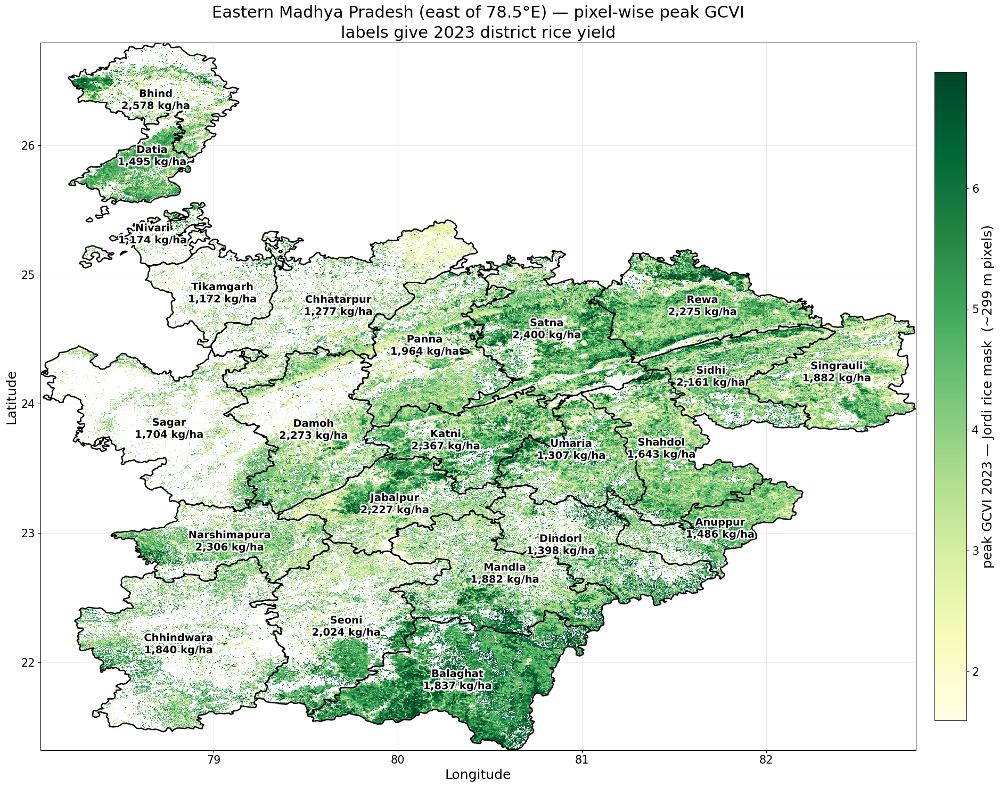

In [4]:
EAST_LON = 78.5          # longitude cut for "eastern MP"
SHOW     = 'jordi'       # 'jordi' or 'raw'

east = G[G.geometry.representative_point().x >= EAST_LON].copy()
east = east.merge(D[['district', 'yield_kg_ha', 'gcvi_jordi', 'npx_jordi']],
                  on='district', how='left')
print(f"{len(east)} districts east of {EAST_LON}°E; "
      f"{east.yield_kg_ha.notna().sum()} have a {YEAR} yield")

from rasterio.mask import mask as rio_mask          # display only: crop to the east
with rasterio.open(TIF[SHOW]) as src:
    arr, tr = rio_mask(src, east.geometry.tolist(), crop=True, filled=True, nodata=0)
    a = to_nan_encoding(arr[0])
    h, w = a.shape
    ext = [tr.c, tr.c + w * tr.a, tr.f + h * tr.e, tr.f]

vmin, vmax = np.nanpercentile(a, [2, 98])
print(f"raster window {w} x {h} px   valid {int(np.isfinite(a).sum()):,}   "
      f"colour {vmin:.2f}-{vmax:.2f}")

fig, ax = plt.subplots(figsize=(19, 15))
im = ax.imshow(a, cmap='YlGn', vmin=vmin, vmax=vmax, extent=ext,
               origin='upper', interpolation='nearest', zorder=2)
east.boundary.plot(ax=ax, edgecolor='black', linewidth=1.8, zorder=3)

for _, r in east.iterrows():
    c = r.geometry.representative_point()
    lab = (f"{r.district}\n{r.yield_kg_ha:,.0f} kg/ha" if np.isfinite(r.yield_kg_ha)
           else f"{r.district}\nno {YEAR} yield")
    ax.annotate(lab, (c.x, c.y), fontsize=14, fontweight='bold', ha='center', va='center',
                zorder=5, linespacing=1.25,
                path_effects=[pe.withStroke(linewidth=4.0, foreground='white')])

cb = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cb.set_label(f'peak GCVI {YEAR} — {LABEL[SHOW]}  (~299 m pixels)', fontsize=18)
cb.ax.tick_params(labelsize=15)
ax.set_xlabel('Longitude', fontsize=18); ax.set_ylabel('Latitude', fontsize=18)
ax.tick_params(labelsize=15); ax.grid(alpha=0.25, lw=0.8); ax.set_aspect('auto')
ax.set_title(f'Eastern {SNAME} (east of {EAST_LON}°E) — pixel-wise peak GCVI\n'
             f'labels give {YEAR} district rice yield', fontsize=22, linespacing=1.4)
plt.tight_layout()
plt.savefig(f'{OUT}/mp_east_pixelwise_{YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Does the mask effect differ across Madhya Pradesh, west to east?

MP is split into three **longitude** bands (the state spans 74.0–82.8°E):

| band | longitude | |
|---|---|---|
| West | 74–76°E | |
| Central | 76–80°E | |
| East | 80°E and beyond | |

A district is assigned by the longitude of its representative point. Within each band
the same pooled correlation is computed across that band's districts, raw and
Jordi-masked, so the bands can be compared on n, r, Δr and slope.

> **On training points.** The repo has no per-district training-point counts — only
> `data/training_points_per_state/train_points_madhya_pradesh.png` (an image) and
> state-level totals in `statewise_report_summary.csv` (MP: 2,844 training points,
> 560 rice). The bands below are therefore a geographic split, not a measured
> training-density split. Counting points per band needs the raw point file
> (lat/lon + class).

In [5]:
BANDS = [('West',    74.0, 76.0),
         ('Central', 76.0, 80.0),
         ('East',    80.0, 83.0)]

G2 = G.copy()
G2['lon'] = G2.geometry.representative_point().x
G2['lat'] = G2.geometry.representative_point().y
DB = D.merge(G2[['district', 'lon', 'lat']], on='district', how='left')

# Pure longitude rule, no hand reassignment. To move districts between bands,
# add entries here, e.g. {'Rajgarh': 'West', 'Jabalpur': 'East'}.
OVERRIDE = {}


def band_of(lon):
    for nm, lo, hi in BANDS:
        if lo <= lon < hi:
            return nm
    return 'outside'

DB['band'] = DB.lon.map(band_of)
DB['band'] = [OVERRIDE.get(d, b) for d, b in zip(DB.district, DB.band)]
DB.to_csv(f'{OUT}/mp_bands_district_{YEAR}.csv', index=False)

for nm, lo, hi in BANDS:
    s = DB[DB.band == nm].sort_values('lon')
    print(f"\n{nm}  ({lo}-{hi}°E):  n = {len(s)} districts")
    print('   ' + ', '.join(f"{r.district} ({r.lon:.1f})"
                            + ('*' if r.district in OVERRIDE else '')
                            for _, r in s.iterrows()))
out = DB[DB.band == 'outside']
if len(out):
    print(f"\nunassigned: {', '.join(out.district)}")
print(f"\ntotal assigned: {(DB.band != 'outside').sum()} of {len(DB)}")
if OVERRIDE:
    print(f"* = moved by hand from its longitude band: {', '.join(OVERRIDE)}")


West  (74.0-76.0°E):  n = 8 districts
   Alirajpur (74.4), Jhabua (74.7), Barwani (74.9), Ratlam (75.0), Nimach (75.2), Mandsaur (75.4), West Nimar (75.8), Indore (75.8)

Central  (76.0-80.0°E):  n = 29 districts
   Dewas (76.3), Burhanpur (76.4), East Nimar (76.6), Shajapur (76.6), Rajgarh (76.8), Sheopur (76.9), Sehore (77.1), Harda (77.1), Guna (77.3), Bhopal (77.4), Shivpuri (77.8), Vidisha (77.8), Morena (77.9), Betul (77.9), Ashoknagar (77.9), Hoshangabad (77.9), Gwalior (78.2), Raisen (78.2), Datia (78.7), Nivari (78.7), Bhind (78.7), Sagar (78.8), Chhindwara (78.8), Tikamgarh (79.0), Narshimapura (79.1), Damoh (79.5), Chhatarpur (79.7), Seoni (79.7), Jabalpur (80.0)

East  (80.0-83.0°E):  n = 12 districts
   Panna (80.1), Katni (80.3), Balaghat (80.3), Mandla (80.6), Satna (80.8), Dindori (80.9), Umaria (80.9), Shahdol (81.4), Rewa (81.7), Sidhi (81.7), Anuppur (81.8), Singrauli (82.4)

total assigned: 49 of 49


In [6]:
rows = []
for nm, lo, hi in BANDS:
    s = DB[DB.band == nm]
    rec = {'band': nm, 'lon': f'{lo:.0f}-{hi:.0f}', 'n': len(s),
           'yield_mean': s.yield_kg_ha.mean(), 'yield_cv': s.yield_kg_ha.std()/s.yield_kg_ha.mean(),
           'rice_px_frac': s.rice_px_frac.mean()}
    for t in ['raw', 'jordi']:
        x, y = s[f'gcvi_{t}'].values, s.yield_kg_ha.values
        r, pv, n = pear(x, y)
        rec[f'r_{t}'], rec[f'p_{t}'] = r, pv
        m = np.isfinite(x) & np.isfinite(y)
        rec[f'b_{t}'] = stats.linregress(x[m], y[m]).slope if m.sum() > 3 else np.nan
        rec[f'sd_{t}'] = np.nanstd(x, ddof=1)
    rec['sR2_raw'], rec['sR2_jordi'] = sr2(rec['r_raw']), sr2(rec['r_jordi'])
    rec['dr'] = rec['r_jordi'] - rec['r_raw']
    rec['dsR2'] = rec['sR2_jordi'] - rec['sR2_raw']
    rows.append(rec)
# whole state for reference
x, y = DB.gcvi_raw.values, DB.yield_kg_ha.values
allrec = {'band': 'ALL MP', 'lon': '74-83', 'n': len(DB),
          'yield_mean': DB.yield_kg_ha.mean(), 'yield_cv': DB.yield_kg_ha.std()/DB.yield_kg_ha.mean(),
          'rice_px_frac': DB.rice_px_frac.mean()}
for t in ['raw', 'jordi']:
    xx = DB[f'gcvi_{t}'].values
    r, pv, n = pear(xx, y)
    allrec[f'r_{t}'], allrec[f'p_{t}'] = r, pv
    m = np.isfinite(xx) & np.isfinite(y)
    allrec[f'b_{t}'] = stats.linregress(xx[m], y[m]).slope
    allrec[f'sd_{t}'] = np.nanstd(xx, ddof=1)
allrec['sR2_raw'], allrec['sR2_jordi'] = sr2(allrec['r_raw']), sr2(allrec['r_jordi'])
allrec['dr'] = allrec['r_jordi'] - allrec['r_raw']
allrec['dsR2'] = allrec['sR2_jordi'] - allrec['sR2_raw']
rows.append(allrec)

B = pd.DataFrame(rows)
B.to_csv(f'{OUT}/mp_bands_summary_{YEAR}.csv', index=False)
print(f"Pooled correlation within each longitude band, {SNAME} {YEAR}")
print("r is one Pearson across that band's districts; n = districts in the band\n")
print(f"{'band':<9}{'n':>4}{'r_raw':>9}{'p_raw':>9}{'r_jordi':>10}{'p_jordi':>10}{'dr':>8}"
      f"{'sR2_raw':>10}{'sR2_jordi':>11}{'dsR2':>9}{'b_raw':>8}{'b_jordi':>9}")
print('-' * 106)
for _, r in B.iterrows():
    print(f"{r.band:<9}{int(r.n):>4}{r.r_raw:>+9.3f}{r.p_raw:>9.4f}"
          f"{r.r_jordi:>+10.3f}{r.p_jordi:>10.4f}{r.dr:>+8.3f}"
          f"{r.sR2_raw:>+10.3f}{r.sR2_jordi:>+11.3f}{r.dsR2:>+9.3f}"
          f"{r.b_raw:>8.0f}{r.b_jordi:>9.0f}")
print(f"\n{'band':<9}{'yield mean':>12}{'yield CV':>10}{'mean rice px frac':>20}")
for _, r in B.iterrows():
    print(f"{r.band:<9}{r.yield_mean:>12.0f}{r.yield_cv:>10.3f}{r.rice_px_frac:>20.3f}")

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


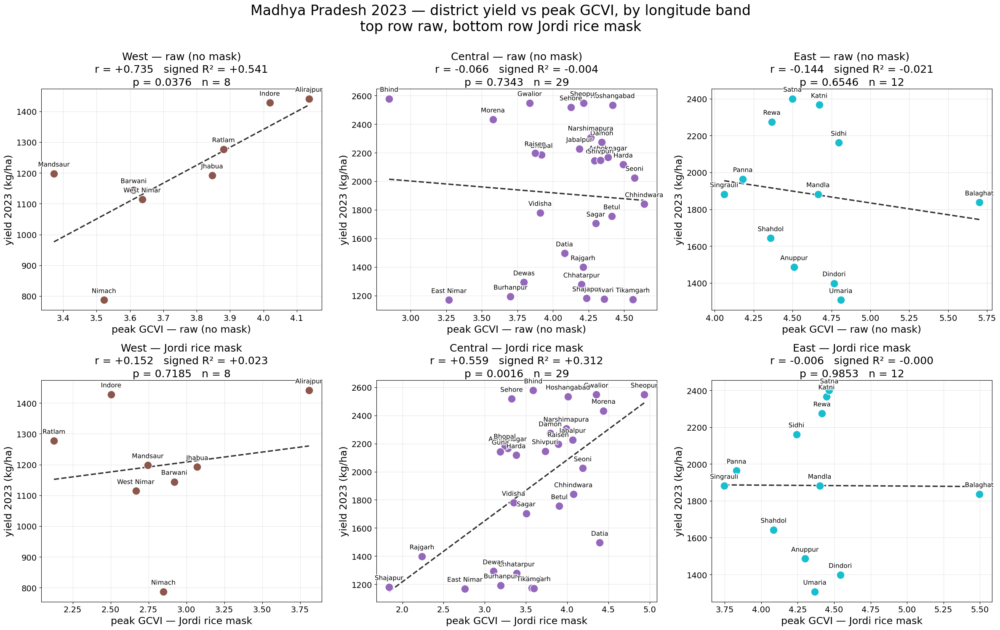

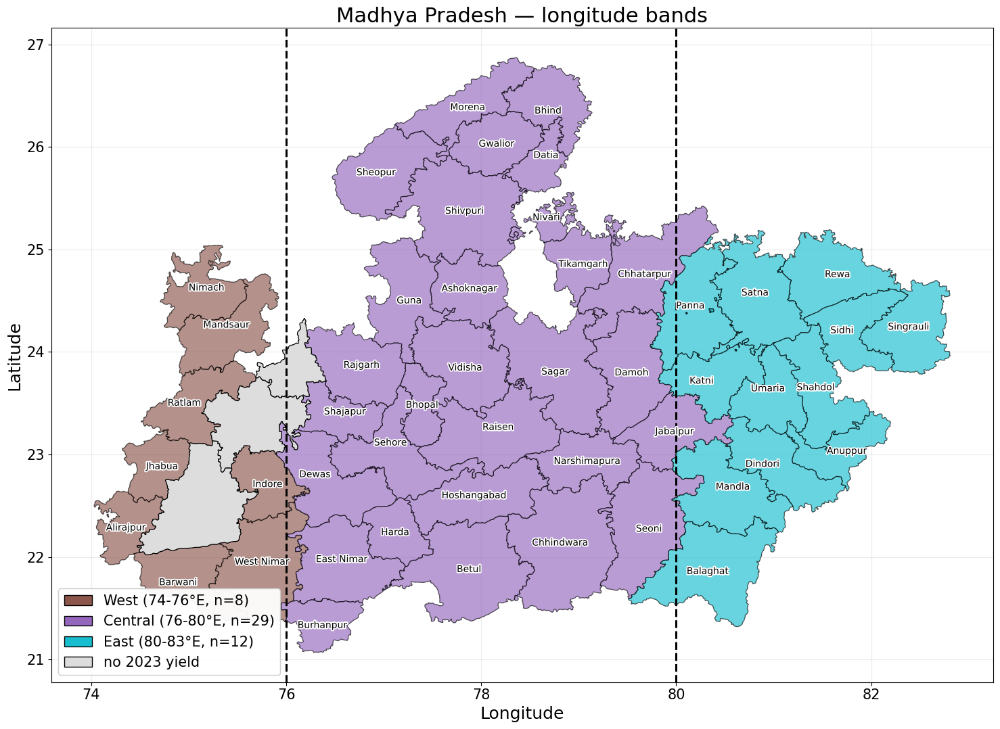

In [7]:
COL = {'West': '#8c564b', 'Central': '#9467bd', 'East': '#17becf'}

fig, axes = plt.subplots(2, 3, figsize=(24, 15))
for j, (nm, lo, hi) in enumerate(BANDS):
    s = DB[DB.band == nm]
    for i, t in enumerate(['raw', 'jordi']):
        ax = axes[i, j]
        x, y = s[f'gcvi_{t}'], s.yield_kg_ha
        ax.scatter(x, y, s=190, color=COL[nm], edgecolors='white', linewidths=1.1, zorder=3)
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() > 3:
            lr = stats.linregress(x[m], y[m])
            xs = np.linspace(x[m].min(), x[m].max(), 40)
            ax.plot(xs, lr.intercept + lr.slope * xs, ls='--', lw=2.4, color='#333', zorder=2)
        for _, r in s.iterrows():
            ax.annotate(r.district, (r[f'gcvi_{t}'], r.yield_kg_ha), fontsize=11,
                        textcoords='offset points', xytext=(0, 12), ha='center', zorder=4,
                        path_effects=[pe.withStroke(linewidth=2.6, foreground='white')])
        rv, pv, n = pear(x.values, y.values)
        ax.set_xlabel(f'peak GCVI — {LABEL[t]}', fontsize=17)
        ax.set_ylabel(f'yield {YEAR} (kg/ha)', fontsize=17)
        ax.tick_params(labelsize=14); ax.grid(alpha=0.3)
        ax.set_title(f'{nm} — {LABEL[t]}\n'
                     f'r = {rv:+.3f}   signed R² = {sr2(rv):+.3f}\n'
                     f'p = {pv:.4f}   n = {n}', fontsize=18, linespacing=1.35)

fig.suptitle(f'{SNAME} {YEAR} — district yield vs peak GCVI, by longitude band\n'
             'top row raw, bottom row Jordi rice mask', y=1.0, fontsize=24)
plt.tight_layout()
plt.savefig(f'{OUT}/mp_bands_scatter_{YEAR}.png', dpi=140, bbox_inches='tight')
plt.show()

# where the bands sit
fig, ax = plt.subplots(figsize=(15, 11))
GB = G.merge(DB[['district', 'band']], on='district', how='left')
for nm, _, _ in BANDS:
    sub = GB[GB.band == nm]
    if len(sub):
        sub.plot(ax=ax, color=COL[nm], edgecolor='black', linewidth=0.9, alpha=0.65, zorder=2)
GB[GB.band.isna()].plot(ax=ax, color='#dddddd', edgecolor='black', linewidth=0.9, zorder=2)
for _, _, hi in BANDS[:-1]:
    ax.axvline(hi, color='black', ls='--', lw=2.2, zorder=4)
for _, r in DB.iterrows():
    ax.annotate(r.district, (r.lon, r.lat), fontsize=10, ha='center', va='center', zorder=5,
                path_effects=[pe.withStroke(linewidth=2.6, foreground='white')])
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=COL[nm], edgecolor='black',
                         label=f'{nm} ({lo:.0f}-{hi:.0f}°E, n={int(B.loc[B.band==nm,"n"].iloc[0])})')
                   for nm, lo, hi in BANDS] +
                  [Patch(facecolor='#dddddd', edgecolor='black', label='no 2023 yield')],
          loc='lower left', fontsize=15, framealpha=0.95)
ax.set_xlabel('Longitude', fontsize=18); ax.set_ylabel('Latitude', fontsize=18)
ax.tick_params(labelsize=15); ax.grid(alpha=0.25); ax.set_aspect('auto')
ax.set_title(f'{SNAME} — longitude bands', fontsize=22)
plt.tight_layout()
plt.savefig(f'{OUT}/mp_bands_map.png', dpi=140, bbox_inches='tight')
plt.show()

### Kharif 2023 rice yield by district, within the three bands

One choropleth of district yield, with the band boundaries drawn on top so the
west-central-east split is visible against the yield pattern.

Colour: sequential **YlGn**, dark green = high yield. A sequential ramp suits a
quantity with a meaningful low end and no natural midpoint; dark-for-high follows the
convention that more vegetation means more yield, and matches the GCVI maps earlier in
this notebook. Band means are printed in the panel on the right.

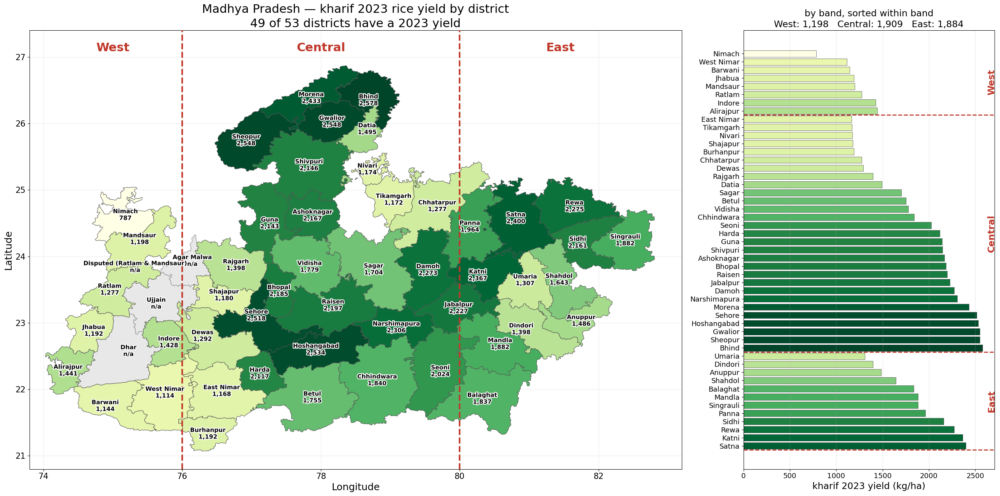

kharif 2023 rice yield (kg/ha) by band

band        n     mean   median      sd     min     max   lowest / highest district
--------------------------------------------------------------------------------------------------------
West        8     1198     1195     206     787    1441   Nimach / Alirajpur
Central    29     1909     2117     502    1168    2578   East Nimar / Bhind
East       12     1884     1882     372    1307    2400   Umaria / Satna
ALL MP     49     1787     1837     504     787    2578


In [8]:
from matplotlib.patches import Patch

GY = G.merge(DB[['district', 'yield_kg_ha', 'band', 'lon', 'lat', 'rice_px_frac']],
             on='district', how='left')
have = GY[GY.yield_kg_ha.notna()]
vmin, vmax = have.yield_kg_ha.min(), have.yield_kg_ha.max()

fig, (ax, axb) = plt.subplots(1, 2, figsize=(26, 13),
                              gridspec_kw={'width_ratios': [2.6, 1]})

GY[GY.yield_kg_ha.isna()].plot(ax=ax, color='#e8e8e8', edgecolor='#888', linewidth=0.8, zorder=2)
have.plot(column='yield_kg_ha', ax=ax, cmap='YlGn', vmin=vmin, vmax=vmax,
          edgecolor='#555', linewidth=0.8, zorder=2)

for _, _, hi in BANDS[:-1]:                       # band cuts
    ax.axvline(hi, color='#c0392b', ls='--', lw=3.0, zorder=5)
for nm, lo, hi in BANDS:
    ax.text((max(lo, 74.0) + min(hi, 82.9)) / 2, 27.05, nm, ha='center', va='bottom',
            fontsize=22, fontweight='bold', color='#c0392b', zorder=6)

for _, r in GY.iterrows():
    c = r.geometry.representative_point()
    lab = (f"{r.district}\n{r.yield_kg_ha:,.0f}" if np.isfinite(r.yield_kg_ha)
           else f"{r.district}\nn/a")
    ax.annotate(lab, (c.x, c.y), fontsize=11, fontweight='bold', ha='center', va='center',
                zorder=6, linespacing=1.2,
                path_effects=[pe.withStroke(linewidth=3.2, foreground='white')])

ax.set_xlim(73.8, 83.2); ax.set_ylim(20.8, 27.4)
ax.set_xlabel('Longitude', fontsize=18); ax.set_ylabel('Latitude', fontsize=18)
ax.tick_params(labelsize=15); ax.grid(alpha=0.25); ax.set_aspect('auto')
ax.set_title(f'{SNAME} — kharif {YEAR} rice yield by district\n'
             f'{len(have)} of {len(GY)} districts have a {YEAR} yield',
             fontsize=22, linespacing=1.35)

# right panel: district yields grouped by band
order = {nm: i for i, (nm, _, _) in enumerate(BANDS)}
s = DB.sort_values(['band', 'yield_kg_ha'], key=lambda c: c.map(order) if c.name == 'band' else c)
ypos = np.arange(len(s))
cols = [plt.get_cmap('YlGn')((v - vmin) / (vmax - vmin)) for v in s.yield_kg_ha]
axb.barh(ypos, s.yield_kg_ha, color=cols, edgecolor='#555', linewidth=0.6)
axb.set_yticks(ypos); axb.set_yticklabels(s.district, fontsize=11)
axb.invert_yaxis()
for nm in order:
    m = (s.band == nm).values
    if m.any():
        mid = ypos[m].mean()
        axb.text(vmax * 1.02, mid, nm, rotation=90, va='center', ha='left',
                 fontsize=17, fontweight='bold', color='#c0392b')
        axb.axhline(ypos[m].max() + 0.5, color='#c0392b', ls='--', lw=2.0)
        axb.axvline(s.yield_kg_ha[m].mean(), color='#c0392b', lw=0, alpha=0)
axb.set_xlabel(f'kharif {YEAR} yield (kg/ha)', fontsize=17)
axb.tick_params(labelsize=13); axb.grid(axis='x', alpha=0.3)
bm = DB.groupby('band').yield_kg_ha.mean().reindex([b[0] for b in BANDS])
axb.set_title('by band, sorted within band\n' +
              '   '.join(f'{k}: {v:,.0f}' for k, v in bm.items()),
              fontsize=17, linespacing=1.3)

plt.tight_layout()
plt.savefig(f'{OUT}/mp_bands_yield_map_{YEAR}.png', dpi=140, bbox_inches='tight')
plt.show()

print(f"kharif {YEAR} rice yield (kg/ha) by band\n")
print(f"{'band':<9}{'n':>4}{'mean':>9}{'median':>9}{'sd':>8}{'min':>8}{'max':>8}   lowest / highest district")
print('-' * 104)
for nm, _, _ in BANDS:
    b_ = DB[DB.band == nm]
    lo_, hi_ = b_.loc[b_.yield_kg_ha.idxmin()], b_.loc[b_.yield_kg_ha.idxmax()]
    print(f"{nm:<9}{len(b_):>4}{b_.yield_kg_ha.mean():>9.0f}{b_.yield_kg_ha.median():>9.0f}"
          f"{b_.yield_kg_ha.std():>8.0f}{b_.yield_kg_ha.min():>8.0f}{b_.yield_kg_ha.max():>8.0f}"
          f"   {lo_.district} / {hi_.district}")
print(f"{'ALL MP':<9}{len(DB):>4}{DB.yield_kg_ha.mean():>9.0f}{DB.yield_kg_ha.median():>9.0f}"
      f"{DB.yield_kg_ha.std():>8.0f}{DB.yield_kg_ha.min():>8.0f}{DB.yield_kg_ha.max():>8.0f}")

### Is the between-band difference real, and why does r differ?

Three additions to the band table:

1. **CIs on each band's r** (Fisher z), and a **forest plot** against the whole-state value.
2. **Interaction test** — fit `yield ~ gcvi * band` on all 49 districts. The interaction
   terms test whether the *slopes* differ between bands, using all the data at once,
   rather than comparing two summary statistics.
3. **Decomposition of r** into slope, sd(GCVI) and residual sd, since
   `r = b·sd(x)/√(b²·sd(x)² + sd(e)²)`. r can differ between bands through any of the
   three, and they carry different meanings: a different slope is a different
   relationship, while the same slope with a different spread is the same relationship
   measured over a narrower window.

Also reported: **leave-one-band-out** pooled r, to see whether the whole-state value
depends on one band.

In [9]:
import itertools

def fisher_ci(r, n, a=0.05):
    if not np.isfinite(r) or n < 4:
        return np.nan, np.nan
    z, se = np.arctanh(r), 1/np.sqrt(n-3)
    c = stats.norm.ppf(1-a/2)
    return np.tanh(z-c*se), np.tanh(z+c*se)

def fisher_diff(r1, n1, r2, n2):
    z = (np.arctanh(r1)-np.arctanh(r2))/np.sqrt(1/(n1-3)+1/(n2-3))
    return z, 2*(1-stats.norm.cdf(abs(z)))

ROWS = []
for t in ['raw', 'jordi']:
    for nm, _, _ in BANDS:
        s = DB[DB.band == nm]
        x, y = s[f'gcvi_{t}'].values, s.yield_kg_ha.values
        m = np.isfinite(x) & np.isfinite(y); x, y = x[m], y[m]
        r = stats.pearsonr(x, y).statistic
        lr = stats.linregress(x, y)
        resid = y - (lr.intercept + lr.slope*x)
        lo, hi = fisher_ci(r, len(x))
        ROWS.append(dict(cond=t, band=nm, n=len(x), r=r, lo=lo, hi=hi, sR2=np.sign(r)*r**2,
                         b=lr.slope, se_b=lr.stderr, sd_x=x.std(ddof=1),
                         sd_res=resid.std(ddof=2), p=stats.pearsonr(x, y).pvalue))
    s = DB
    x, y = s[f'gcvi_{t}'].values, s.yield_kg_ha.values
    m = np.isfinite(x) & np.isfinite(y); x, y = x[m], y[m]
    r = stats.pearsonr(x, y).statistic; lr = stats.linregress(x, y)
    lo, hi = fisher_ci(r, len(x))
    ROWS.append(dict(cond=t, band='ALL MP', n=len(x), r=r, lo=lo, hi=hi, sR2=np.sign(r)*r**2,
                     b=lr.slope, se_b=lr.stderr, sd_x=x.std(ddof=1),
                     sd_res=(y-(lr.intercept+lr.slope*x)).std(ddof=2),
                     p=stats.pearsonr(x, y).pvalue))
H = pd.DataFrame(ROWS)
H.to_csv(f'{OUT}/mp_bands_heterogeneity_{YEAR}.csv', index=False)

for t in ['raw', 'jordi']:
    print(f"\n=== {LABEL[t]} ===")
    print(f"{'band':<9}{'n':>4}{'r':>8}{'95% CI':>18}{'p':>9}{'slope b':>10}{'se(b)':>9}"
          f"{'sd_x':>8}{'sd_res':>9}")
    print('-'*84)
    for _, x_ in H[H.cond == t].iterrows():
        print(f"{x_.band:<9}{int(x_.n):>4}{x_.r:>+8.3f}"
              f"{f'[{x_.lo:+.2f}, {x_.hi:+.2f}]':>18}{x_.p:>9.4f}"
              f"{x_.b:>10.0f}{x_.se_b:>9.0f}{x_.sd_x:>8.3f}{x_.sd_res:>9.0f}")
    print("  pairwise Fisher z (independent samples):")
    sub = H[(H.cond == t) & (H.band != 'ALL MP')]
    for (_, a_), (_, b_) in itertools.combinations(sub.iterrows(), 2):
        z, pv = fisher_diff(a_.r, a_.n, b_.r, b_.n)
        print(f"    {a_.band:<8} vs {b_.band:<8} z = {z:+.2f}   p = {pv:.4f}"
              + ('  *' if pv < .05 else ''))

def ols(X, y):
    """Least squares with SEs and p-values; avoids a statsmodels dependency."""
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    res = y - X @ beta
    rss = float(res @ res); n, k = X.shape
    cov = (rss / (n - k)) * np.linalg.pinv(X.T @ X)
    se = np.sqrt(np.diag(cov))
    return beta, se, 2 * (1 - stats.t.cdf(np.abs(beta / se), n - k)), rss, n, k


print("\n\n=== interaction test: yield ~ gcvi * band  (West = reference) ===")
names = [b[0] for b in BANDS]
for t in ['raw', 'jordi']:
    d = DB[[f'gcvi_{t}', 'yield_kg_ha', 'band']].dropna()
    x, y = d[f'gcvi_{t}'].values, d.yield_kg_ha.values
    D1 = (d.band == names[1]).values.astype(float)
    D2 = (d.band == names[2]).values.astype(float)
    Xr = np.column_stack([np.ones_like(x), x, D1, D2])                  # one common slope
    Xf = np.column_stack([np.ones_like(x), x, D1, D2, x * D1, x * D2])  # slope per band
    _, _, _, rss_r, n, kr = ols(Xr, y)
    bf, sef, pvf, rss_f, _, kf = ols(Xf, y)
    F = ((rss_r - rss_f) / (kf - kr)) / (rss_f / (n - kf))
    pv = 1 - stats.f.cdf(F, kf - kr, n - kf)
    print(f"\n{LABEL[t]}: F = {F:.2f}  p = {pv:.4f}  df = ({kf-kr}, {n-kf})"
          "   H0: same slope in all bands")
    lab = ['intercept', 'gcvi (West slope)', f'{names[1]} intercept shift',
           f'{names[2]} intercept shift', f'gcvi x {names[1]}', f'gcvi x {names[2]}']
    for l, b_, s_, p_ in zip(lab, bf, sef, pvf):
        print(f"    {l:<26}{b_:>10.0f}  se {s_:>8.0f}  p = {p_:.4f}")
    print(f"    implied slopes: West {bf[1]:,.0f}   {names[1]} {bf[1]+bf[4]:,.0f}"
          f"   {names[2]} {bf[1]+bf[5]:,.0f}")

print("\n\n=== leave-one-band-out pooled r ===")
print(f"{'dropped':<12}{'n':>4}{'r_raw':>10}{'r_jordi':>10}")
print('-'*36)
for nm in ['(none)'] + [b[0] for b in BANDS]:
    d = DB if nm == '(none)' else DB[DB.band != nm]
    vals = []
    for t in ['raw', 'jordi']:
        x, y = d[f'gcvi_{t}'].values, d.yield_kg_ha.values
        m = np.isfinite(x) & np.isfinite(y)
        vals.append(stats.pearsonr(x[m], y[m]).statistic)
    print(f"{nm:<12}{len(d):>4}{vals[0]:>+10.3f}{vals[1]:>+10.3f}")

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


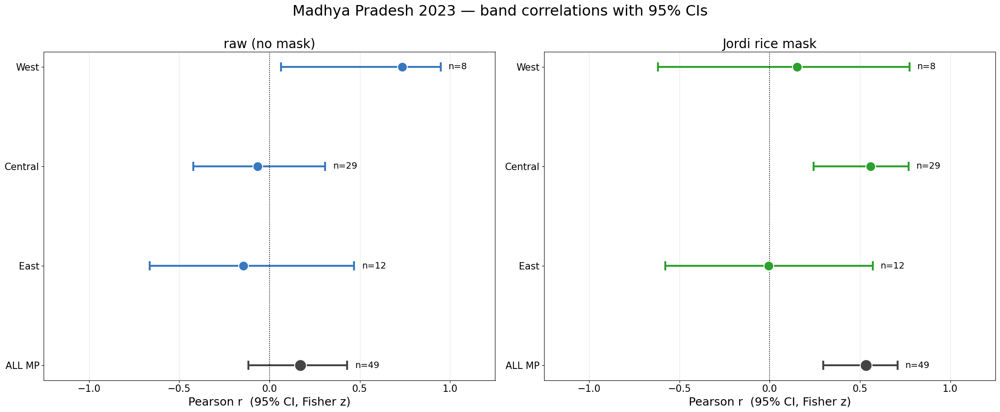

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(22, 9))
for ax, t in zip(axes, ['raw', 'jordi']):
    s = H[H.cond == t].iloc[::-1].reset_index(drop=True)
    for i, r_ in s.iterrows():
        c = '#444444' if r_.band == 'ALL MP' else ('#2ca02c' if t == 'jordi' else '#3778bf')
        ax.errorbar(r_.r, i, xerr=[[r_.r - r_.lo], [r_.hi - r_.r]], fmt='none',
                    ecolor=c, elinewidth=3, capsize=7, capthick=3, zorder=2)
        ax.scatter(r_.r, i, s=340 if r_.band == 'ALL MP' else 230, color=c,
                   edgecolors='white', linewidths=1.4, zorder=3)
        ax.annotate(f"n={int(r_.n)}", (r_.hi, i), fontsize=14,
                    textcoords='offset points', xytext=(12, 0), va='center')
    ax.axvline(0, color='black', lw=1.2, ls=':')
    ax.set_yticks(np.arange(len(s))); ax.set_yticklabels(s.band, fontsize=17)
    ax.set_xlim(-1.25, 1.25)
    ax.set_xlabel('Pearson r  (95% CI, Fisher z)', fontsize=18)
    ax.tick_params(labelsize=15); ax.grid(axis='x', alpha=0.3)
    ax.set_title(LABEL[t], fontsize=20)

fig.suptitle(f'{SNAME} {YEAR} — band correlations with 95% CIs', y=1.0, fontsize=23)
plt.tight_layout()
plt.savefig(f'{OUT}/mp_bands_forest_{YEAR}.png', dpi=140, bbox_inches='tight')
plt.show()

## 4. Moving window: does the mask benefit track rice share?

Rather than splitting districts into bands by eye, sort them by **census rice share**
and compute the pooled correlation in overlapping windows of `k` districts. `BASKET`
in the next cell switches the denominator: `None` = all kharif crops (the agronomic
quantity, used below), `MAP5` = only the crops the classifier has classes for. Each window
gives `r_raw`, `r_jordi` and `Δr` at a known mean rice share.

Plotting all three matters: if Δr rises because the masked correlation improves, the
`r_jordi` line climbs; if it rises because the raw correlation degrades, `r_raw` falls
faster. Those are different claims.

**States: Madhya Pradesh and Telangana**, the two carried forward from a scan of all 27.
MP has the widest rice-share spread in the country (sd 0.430); Telangana is the closest
match to MP on kharif crop diversity (entropy 0.855 vs 0.822, 10.6 vs 11.5 crops).

**Significance comes from a permutation test**, not from the window count. Windows
overlap by `k−1` districts, so the curve is smooth whatever the ordering — random
shuffles of rice share give |ρ| > 0.5 about half the time. The test shuffles the
rice-share column across districts (GCVI and yield stay with their district), reruns the
whole pipeline, and asks how often chance reproduces the observed ρ.

Denominator note: using rice share of **all** kharif crops instead of the 5-crop basket
gives MP ρ = +0.775, p = 0.16 rather than ρ = +0.953, p = 0.004. The basket version is
the like-for-like measure — it is the share of what the classifier can actually see —
but the choice was made after seeing both, so treat the p-value as uncorrected.

In [11]:
import glob as _glob

PANEL = pd.read_csv(f'{OUT}/gcvi_2023_300m_district_panel.csv')
MAP5 = ['Rice', 'Maize', 'Cotton', 'Sugarcane', 'Peas']   # the map's crop classes
AGG  = {'Total Food Grains', 'Cereals', 'Total Pulses',
        'Nutri/Coarse Cereals', 'Shree Anna /Nutri Cereals'}   # DES subtotal rows

# BASKET = None  -> rice share of ALL kharif crops (the agronomic quantity)
# BASKET = MAP5  -> rice share of the crops the classifier has classes for
BASKET = None


def census_share(state_name, basket=None):
    """District rice share of either all kharif crops or a named basket, for YEAR."""
    rows = []
    for f in sorted(_glob.glob(f'{ROOT}/data/yield/DES-District-Data-For-*.csv')):
        x = pd.read_csv(f, encoding='utf-8-sig')
        s = x[(x.State == state_name) & (x.Season == 'Kharif')]
        for col in [c for c in x.columns if c.startswith('Area-')]:
            yr = int(re.search(r'Area-(\d{4})', col).group(1))
            t = s[['District', 'Crop', col]].copy()
            t.columns = ['district', 'crop', 'area']
            t['area'] = pd.to_numeric(t.area, errors='coerce'); t['year'] = yr
            rows.append(t)
    a = pd.concat(rows, ignore_index=True).dropna(subset=['area'])
    a = a[(a.year == YEAR) & (a.area > 0)]
    a = a[a.crop.isin(basket)] if basket else a[~a.crop.isin(AGG)]
    a['district'] = (a.district.str.strip().str.title()
                     .str.replace(r'\s+', ' ', regex=True).replace(CFG['NAME_FIXES']))
    tot = a.groupby('district').area.sum().rename('basket_ha')
    ric = a[a.crop == 'Rice'].groupby('district').area.sum().rename('rice_ha')
    out = pd.concat([tot, ric], axis=1).fillna({'rice_ha': 0}).reset_index()
    out['rice_share'] = out.rice_ha / out.basket_ha
    return out[['district', 'rice_share', 'rice_ha']]


def state_frame(key):
    """districts x (raw GCVI, Jordi GCVI, yield, census rice share) for one state."""
    a = PANEL[(PANEL.region_key == key) & (PANEL.type == 'raw_300m')][
        ['district', 'gcvi_mean', 'yield_kg_ha']].rename(columns={'gcvi_mean': 'raw'})
    b = PANEL[(PANEL.region_key == key) & (PANEL.type == 'jordi_300m')][
        ['district', 'gcvi_mean']].rename(columns={'gcvi_mean': 'jordi'})
    sh = census_share(REGIONS[key]['state_name'], BASKET)
    return a.merge(b, on='district').merge(sh, on='district').dropna()


def windows(df, k=15, step=1, col='rice_share'):
    s = df.sort_values(col).reset_index(drop=True); out = []
    for i in range(0, len(s) - k + 1, step):
        w = s.iloc[i:i + k]
        if w.raw.nunique() < 3 or w.yield_kg_ha.nunique() < 3:
            continue
        rr = stats.pearsonr(w.raw, w.yield_kg_ha).statistic
        rj = stats.pearsonr(w.jordi, w.yield_kg_ha).statistic
        out.append(dict(share=w[col].mean(), lo=w[col].min(), hi=w[col].max(),
                        r_raw=rr, r_jordi=rj, dr=rj - rr))
    return pd.DataFrame(out)


def perm_test(df, k=15, n=2000, seed=0):
    """Shuffle rice share; the null keeps the overlap-induced smoothness."""
    obs = stats.spearmanr(*windows(df, k)[['share', 'dr']].values.T).statistic
    rng = np.random.default_rng(seed); null = []
    for _ in range(n):
        q = df.copy(); q['rice_share'] = rng.permutation(q.rice_share.values)
        W = windows(q, k)
        if len(W) > 3:
            null.append(stats.spearmanr(W.share, W.dr).statistic)
    null = np.array(null)
    return obs, (np.abs(null) >= abs(obs)).mean(), null


CMP = {'mp': 'Madhya Pradesh', 'telangana': 'Telangana'}
FR = {k: state_frame(k) for k in CMP}
DENOM = '5-crop basket' if BASKET else 'all kharif crops'
print(f"rice share denominator: {DENOM}\n")
for k, nm in CMP.items():
    print(f"{nm:<18} n = {len(FR[k]):>3} districts   "
          f"rice share {FR[k].rice_share.min():.3f}-{FR[k].rice_share.max():.3f}")

rice share denominator: all kharif crops

Madhya Pradesh     n =  49 districts   rice share 0.000-0.970
Telangana          n =  32 districts   rice share 0.003-0.976


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


...

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


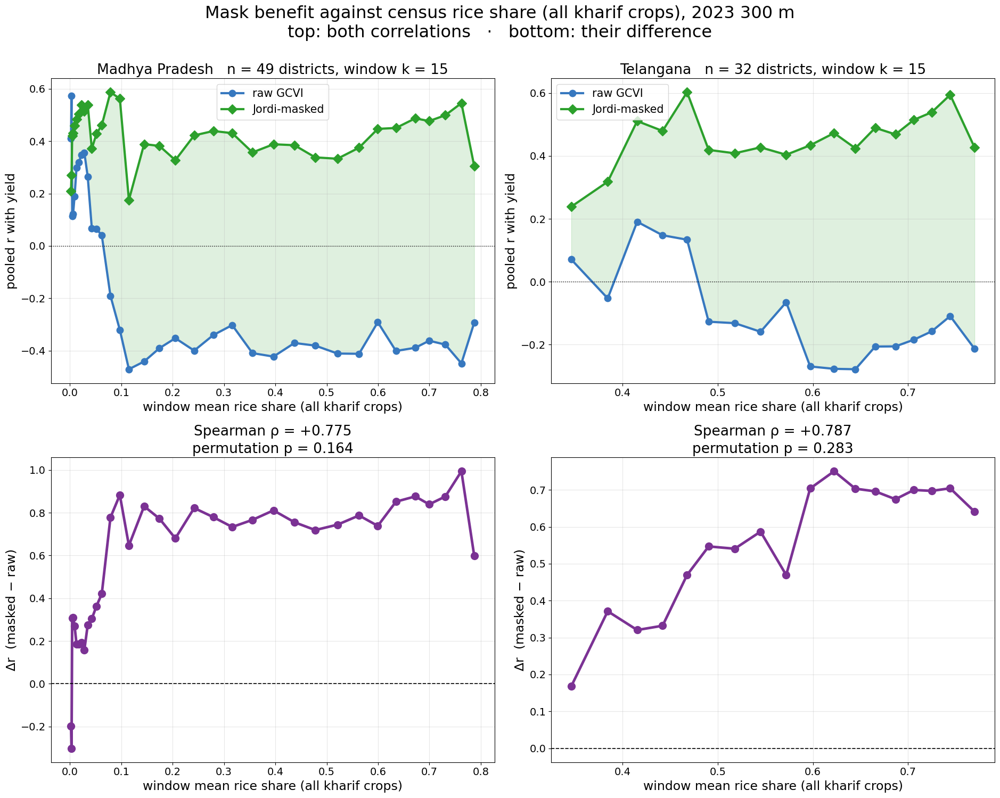

state                n   k   rho(share, dr)   perm p           r_raw range           r_jordi range
--------------------------------------------------------------------------------------------------
Madhya Pradesh      49  15           +0.775    0.164      +0.410 -> -0.293        +0.210 -> +0.305
Telangana           32  15           +0.787    0.283      +0.070 -> -0.213        +0.239 -> +0.428


In [12]:
K = 15
fig, axes = plt.subplots(2, 2, figsize=(19, 15))
res = {}
for j, (key, nm) in enumerate(CMP.items()):
    df = FR[key]
    kk = K if len(df) >= 22 else max(8, len(df) // 2)
    W = windows(df, kk)
    obs, pv, _ = perm_test(df, kk, n=3000, seed=1)
    res[key] = dict(n=len(df), k=kk, rho=obs, p=pv, W=W)

    ax = axes[0, j]
    ax.plot(W.share, W.r_raw,   'o-', lw=3, ms=9, color='#3778bf', label='raw GCVI')
    ax.plot(W.share, W.r_jordi, 'D-', lw=3, ms=9, color='#2ca02c', label='Jordi-masked')
    ax.fill_between(W.share, W.r_raw, W.r_jordi,
                    where=W.r_jordi >= W.r_raw, color='#2ca02c', alpha=0.15)
    ax.fill_between(W.share, W.r_raw, W.r_jordi,
                    where=W.r_jordi <  W.r_raw, color='#c0504d', alpha=0.15)
    ax.axhline(0, color='black', lw=1, ls=':')
    ax.set_xlabel(f'window mean rice share ({DENOM})', fontsize=17)
    ax.set_ylabel('pooled r with yield', fontsize=17)
    ax.tick_params(labelsize=14); ax.grid(alpha=0.3); ax.legend(fontsize=15)
    ax.set_title(f'{nm}   n = {len(df)} districts, window k = {kk}', fontsize=19)

    ax = axes[1, j]
    ax.plot(W.share, W.dr, 'o-', lw=3.5, ms=10, color='#7b3294')
    ax.axhline(0, color='black', lw=1.2, ls='--')
    ax.set_xlabel(f'window mean rice share ({DENOM})', fontsize=17)
    ax.set_ylabel('Δr  (masked − raw)', fontsize=17)
    ax.tick_params(labelsize=14); ax.grid(alpha=0.3)
    ax.set_title(f'Spearman ρ = {obs:+.3f}\npermutation p = {pv:.3f}',
                 fontsize=19, linespacing=1.35)

fig.suptitle(f'Mask benefit against census rice share ({DENOM}), {YEAR} 300 m\n'
             'top: both correlations   ·   bottom: their difference',
             y=1.0, fontsize=23)
plt.tight_layout()
plt.savefig(f'{OUT}/moving_window_riceshare_{"basket5" if BASKET else "allkharif"}_{YEAR}.png', dpi=140, bbox_inches='tight')
plt.show()

print(f"{'state':<18}{'n':>4}{'k':>4}{'rho(share, dr)':>17}{'perm p':>9}"
      f"{'r_raw range':>22}{'r_jordi range':>24}")
print('-'*98)
for key, nm in CMP.items():
    r_ = res[key]; W = r_['W']
    print(f"{nm:<18}{r_['n']:>4}{r_['k']:>4}{r_['rho']:>+17.3f}{r_['p']:>9.3f}"
          f"{f'{W.r_raw.iloc[0]:+.3f} -> {W.r_raw.iloc[-1]:+.3f}':>22}"
          f"{f'{W.r_jordi.iloc[0]:+.3f} -> {W.r_jordi.iloc[-1]:+.3f}':>24}")

state                k  windows   rho(share,dr)   rho(share,r_raw)   rho(share,r_jordi)
---------------------------------------------------------------------------------------
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Madhya Pradesh      10       40          +0.763             -0.736               +0.402
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) 

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
                    20       13          +0.775             -0.665               +0.181
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Libra

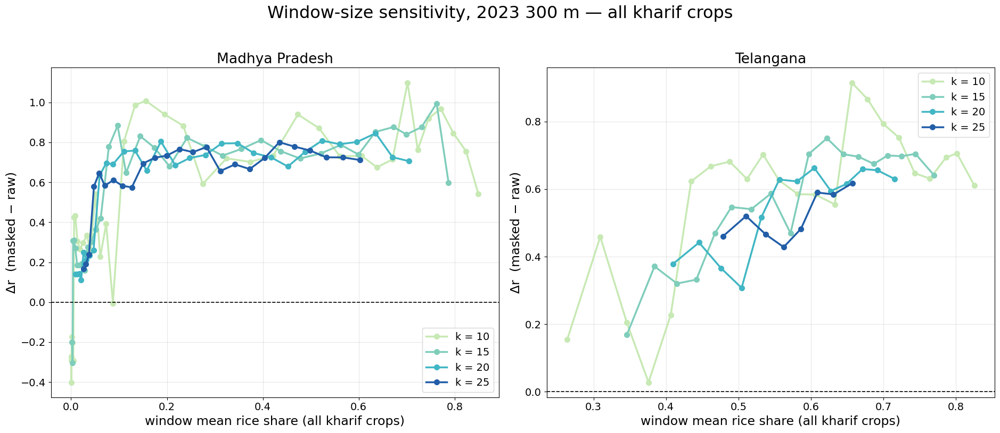

In [13]:
# window-size sensitivity, and what drives the trend in each state
print(f"{'state':<18}{'k':>4}{'windows':>9}{'rho(share,dr)':>16}"
      f"{'rho(share,r_raw)':>19}{'rho(share,r_jordi)':>21}")
print('-'*87)
for key, nm in CMP.items():
    df = FR[key]
    for kk in [10, 15, 20, 25]:
        if kk > len(df) - 4:
            continue
        W = windows(df, kk)
        if len(W) < 4:
            continue
        print(f"{nm if kk == 10 else '':<18}{kk:>4}{len(W):>9}"
              f"{stats.spearmanr(W.share, W.dr).statistic:>+16.3f}"
              f"{stats.spearmanr(W.share, W.r_raw).statistic:>+19.3f}"
              f"{stats.spearmanr(W.share, W.r_jordi).statistic:>+21.3f}")

fig, axes = plt.subplots(1, 2, figsize=(19, 8))
for ax, (key, nm) in zip(axes, CMP.items()):
    df = FR[key]
    for kk, c in zip([10, 15, 20, 25], ['#c7e9b4', '#7fcdbb', '#41b6c4', '#225ea8']):
        if kk > len(df) - 4:
            continue
        W = windows(df, kk)
        if len(W) >= 4:
            ax.plot(W.share, W.dr, 'o-', lw=2.5, ms=7, color=c, label=f'k = {kk}')
    ax.axhline(0, color='black', lw=1.2, ls='--')
    ax.set_xlabel(f'window mean rice share ({DENOM})', fontsize=17)
    ax.set_ylabel('Δr  (masked − raw)', fontsize=17)
    ax.tick_params(labelsize=14); ax.grid(alpha=0.3); ax.legend(fontsize=14)
    ax.set_title(nm, fontsize=19)
fig.suptitle(f'Window-size sensitivity, {YEAR} 300 m — {DENOM}', y=1.02, fontsize=23)
plt.tight_layout()
plt.savefig(f'{OUT}/moving_window_ksensitivity_{"basket5" if BASKET else "allkharif"}_{YEAR}.png', dpi=140, bbox_inches='tight')
plt.show()

## 5. Telangana — the same section analysis

MP was split on longitude alone. Telangana is split to follow the **training-point
distribution**: the crop-map training points form a western cluster ending near 78.2°E
and an eastern cluster starting near 79.2°E, with a sparse middle. The cuts are placed
in that gap, so the Central band is the one with few training points.

| band | longitude | |
|---|---|---|
| West | < 78.2°E | training points present |
| Central | 78.2–79.2°E | few training points |
| East | ≥ 79.2°E | training points present |

Same outputs as for MP: a section map, per-band scatters (raw on top, Jordi below), and
the band correlation table.

In [14]:
TG_KEY, TG_NAME = 'telangana', 'Telangana'
TG_BANDS = [('West', 76.0, 78.2), ('Central', 78.2, 79.2), ('East', 79.2, 81.5)]
BAND_COL = {'West': '#8c564b', 'Central': '#9467bd', 'East': '#17becf'}


def state_bands(key, state_name, bands):
    """districts x (raw, jordi, yield, census rice share, lon/lat, band) for one state."""
    a = PANEL[(PANEL.region_key == key) & (PANEL.type == 'raw_300m')][
        ['district', 'gcvi_mean', 'yield_kg_ha']].rename(columns={'gcvi_mean': 'gcvi_raw'})
    b = PANEL[(PANEL.region_key == key) & (PANEL.type == 'jordi_300m')][
        ['district', 'gcvi_mean']].rename(columns={'gcvi_mean': 'gcvi_jordi'})
    g = gpd.read_file(REGIONS[key]['shp']).to_crs('EPSG:4326')
    g = g[g.geometry.notna() & ~g.geometry.is_empty]
    g['district'] = g['gaul2_name'].str.strip().str.title().str.replace(r'\s+', ' ', regex=True)
    g['lon'] = g.geometry.representative_point().x
    g['lat'] = g.geometry.representative_point().y
    d = (a.merge(b, on='district')
           .merge(census_share(state_name, BASKET), on='district')
           .merge(g[['district', 'lon', 'lat']], on='district').dropna())
    def which(l):
        for nm, lo, hi in bands:
            if lo <= l < hi:
                return nm
        return 'outside'
    d['band'] = d.lon.map(which)
    return d, g


TG, TG_G = state_bands(TG_KEY, TG_NAME, TG_BANDS)
TG.to_csv(f'{OUT}/telangana_bands_district_{YEAR}.csv', index=False)
for nm, lo, hi in TG_BANDS:
    s = TG[TG.band == nm].sort_values('lon')
    print(f"\n{nm} ({lo}-{hi}°E): n = {len(s)}")
    print('   ' + ', '.join(f"{r.district} ({r.lon:.1f})" for _, r in s.iterrows()))
print(f"\ntotal assigned {(TG.band != 'outside').sum()} of {len(TG)}")


West (76.0-78.2°E): n = 8
   Narayanpet (77.6), Sangareddy (77.7), Jogulamba Gadwal (77.7), Vikarabad (77.7), Mahabubnagar (77.9), Wanaparthy (78.0), Kamareddy (78.1), Nizamabad (78.2)

Central (78.2-79.2°E): n = 10
   Medak (78.2), Nirmal (78.4), Rangareddy (78.4), Medchal-Malkajgiri (78.5), Adilabad (78.6), Nagarkurnool (78.7), Ranjanna Sircilla (78.8), Siddipet (78.9), Jagtial (78.9), Yadadri Bhuvanagiri (79.1)

East (79.2-81.5°E): n = 14
   Nalgonda (79.2), Karimnagar (79.3), Jangaon (79.3), Kumuram Bheem (79.4), Warangal (Urban) (79.5), Peddapalli (79.5), Mancherial (79.5), Suryapet (79.8), Warangal (Rural) (79.8), Jayashankar Bhupalapally (80.0), Mahabubabad (80.1), Mulugu (80.3), Khammam (80.4), Bhadradri Kothagudem (80.6)

total assigned 32 of 32


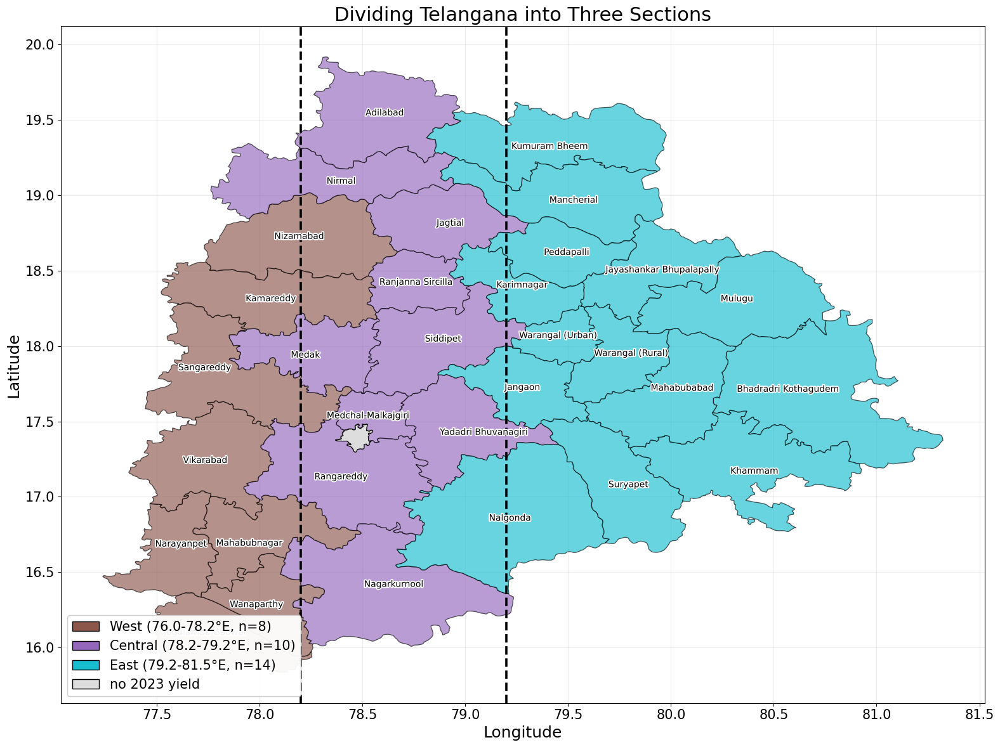

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


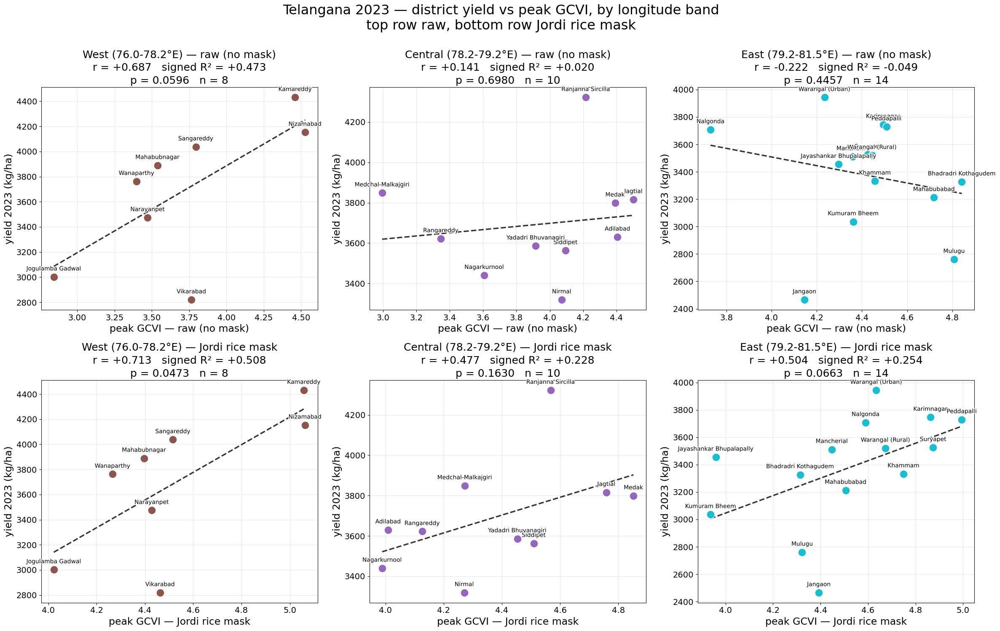

pooled correlation within each band, Telangana 2023

band        n    r_raw        p   r_jordi        p       dr   sR2_raw  sR2_jordi     dsR2    b_raw  b_jordi  rice_sh   yield
----------------------------------------------------------------------------------------------------------------------------
West        8   +0.687   0.0596    +0.713   0.0473   +0.025    +0.473     +0.508   +0.035      692     1101    0.485    3696
Central    10   +0.141   0.6980    +0.477   0.1630   +0.337    +0.020     +0.228   +0.208       79      442    0.593    3695
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
East       14   -0.222   0.4457    +0.504   0.0663   +0.726    -0.049     +0.254   +0.303     -316      637    0.578    3377
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (In

In [15]:
def band_map(df, gdf, bands, title, outfile):
    GB = gdf.merge(df[['district', 'band']], on='district', how='left')
    fig, ax = plt.subplots(figsize=(16, 12))
    for nm, _, _ in bands:
        sub = GB[GB.band == nm]
        if len(sub):
            sub.plot(ax=ax, color=BAND_COL[nm], edgecolor='black', linewidth=0.9,
                     alpha=0.65, zorder=2)
    nb_ = GB[GB.band.isna()]
    if len(nb_):
        nb_.plot(ax=ax, color='#dddddd', edgecolor='black', linewidth=0.9, zorder=2)
    for _, _, hi in bands[:-1]:
        ax.axvline(hi, color='black', ls='--', lw=2.6, zorder=4)
    for _, r in df.iterrows():
        ax.annotate(r.district, (r.lon, r.lat), fontsize=10, ha='center', va='center',
                    zorder=5, path_effects=[pe.withStroke(linewidth=2.6, foreground='white')])
    from matplotlib.patches import Patch
    n = df.band.value_counts()
    ax.legend(handles=[Patch(facecolor=BAND_COL[nm], edgecolor='black',
                             label=f'{nm} ({lo:.1f}-{hi:.1f}°E, n={int(n.get(nm, 0))})')
                       for nm, lo, hi in bands] +
                      ([Patch(facecolor='#dddddd', edgecolor='black', label=f'no {YEAR} yield')]
                       if len(nb_) else []),
              loc='lower left', fontsize=15, framealpha=0.95)
    ax.set_xlabel('Longitude', fontsize=18); ax.set_ylabel('Latitude', fontsize=18)
    ax.tick_params(labelsize=15); ax.grid(alpha=0.25); ax.set_aspect('auto')
    ax.set_title(title, fontsize=22)
    plt.tight_layout(); plt.savefig(outfile, dpi=140, bbox_inches='tight'); plt.show()


def band_scatters(df, bands, state_name, outfile):
    fig, axes = plt.subplots(2, len(bands), figsize=(8 * len(bands), 15))
    for j, (nm, lo, hi) in enumerate(bands):
        s = df[df.band == nm]
        for i, (col, lab) in enumerate([('gcvi_raw', 'raw (no mask)'),
                                        ('gcvi_jordi', 'Jordi rice mask')]):
            ax = axes[i, j]
            x, y = s[col], s.yield_kg_ha
            ax.scatter(x, y, s=190, color=BAND_COL[nm], edgecolors='white',
                       linewidths=1.1, zorder=3)
            m = np.isfinite(x) & np.isfinite(y)
            if m.sum() > 3:
                lr = stats.linregress(x[m], y[m])
                xs = np.linspace(x[m].min(), x[m].max(), 40)
                ax.plot(xs, lr.intercept + lr.slope * xs, ls='--', lw=2.4,
                        color='#333', zorder=2)
            for _, r in s.iterrows():
                ax.annotate(r.district, (r[col], r.yield_kg_ha), fontsize=10,
                            textcoords='offset points', xytext=(0, 11), ha='center',
                            zorder=4,
                            path_effects=[pe.withStroke(linewidth=2.6, foreground='white')])
            rv, pv = stats.pearsonr(x, y)
            ax.set_xlabel(f'peak GCVI — {lab}', fontsize=17)
            ax.set_ylabel(f'yield {YEAR} (kg/ha)', fontsize=17)
            ax.tick_params(labelsize=14); ax.grid(alpha=0.3)
            ax.set_title(f'{nm} ({lo:.1f}-{hi:.1f}°E) — {lab}\n'
                         f'r = {rv:+.3f}   signed R² = {np.sign(rv)*rv**2:+.3f}\n'
                         f'p = {pv:.4f}   n = {len(s)}', fontsize=18, linespacing=1.35)
    fig.suptitle(f'{state_name} {YEAR} — district yield vs peak GCVI, by longitude band\n'
                 'top row raw, bottom row Jordi rice mask', y=1.0, fontsize=23)
    plt.tight_layout(); plt.savefig(outfile, dpi=140, bbox_inches='tight'); plt.show()


def band_table(df, bands, state_name):
    print(f"pooled correlation within each band, {state_name} {YEAR}\n")
    print(f"{'band':<9}{'n':>4}{'r_raw':>9}{'p':>9}{'r_jordi':>10}{'p':>9}{'dr':>9}"
          f"{'sR2_raw':>10}{'sR2_jordi':>11}{'dsR2':>9}{'b_raw':>9}{'b_jordi':>9}"
          f"{'rice_sh':>9}{'yield':>8}")
    print('-' * 124)
    for nm in [b[0] for b in bands] + ['ALL']:
        s = df if nm == 'ALL' else df[df.band == nm]
        if len(s) < 4:
            print(f"{nm:<9}{len(s):>4}   too few districts"); continue
        rr = stats.pearsonr(s.gcvi_raw, s.yield_kg_ha)
        rj = stats.pearsonr(s.gcvi_jordi, s.yield_kg_ha)
        br = stats.linregress(s.gcvi_raw, s.yield_kg_ha).slope
        bj = stats.linregress(s.gcvi_jordi, s.yield_kg_ha).slope
        sr, sj = np.sign(rr.statistic)*rr.statistic**2, np.sign(rj.statistic)*rj.statistic**2
        print(f"{nm:<9}{len(s):>4}{rr.statistic:>+9.3f}{rr.pvalue:>9.4f}"
              f"{rj.statistic:>+10.3f}{rj.pvalue:>9.4f}{rj.statistic-rr.statistic:>+9.3f}"
              f"{sr:>+10.3f}{sj:>+11.3f}{sj-sr:>+9.3f}{br:>9.0f}{bj:>9.0f}"
              f"{s.rice_share.mean():>9.3f}{s.yield_kg_ha.mean():>8.0f}")


band_map(TG, TG_G, TG_BANDS, f'Dividing {TG_NAME} into Three Sections',
         f'{OUT}/telangana_bands_map.png')
band_scatters(TG, TG_BANDS, TG_NAME, f'{OUT}/telangana_bands_scatter_{YEAR}.png')
band_table(TG, TG_BANDS, TG_NAME)

## 6. Maharashtra — the same section analysis

Only **22 of 36** districts have a 2023 kharif rice yield. The 14 without are almost
entirely the central cotton/soybean belt — Aurangabad, Jalna, Bid, Buldhana, Parbhani,
Hingoli, Akola, Washim, Yavatmal, Wardha — plus the two Mumbai districts. So the
matched districts fall into three groups separated by real gaps in longitude:

    73.09 ... 74.86   |  76.12 ... 77.64  |  79.02 ... 80.27
       13 districts         4 districts        5 districts

Cuts are placed in those gaps (75.5 and 78.3) rather than at round numbers.

> **Central has n = 4.** The critical |r| for p < 0.05 at n = 4 is 0.950, so that band's
> correlation is reported but cannot distinguish anything. A two-band West/East split is
> printed underneath as the version with usable sample sizes.


West (72.0-75.5°E): n = 13
   Palghar (73.1), Raygad (73.1), Thane (73.4), Ratnagiri (73.5), Sindhudurg (73.7), Pune (73.9), Kolhapur (74.1), Nashik (74.1), Satara (74.3), Dhule (74.5), Nandurbar (74.5), Sangli (74.6), Ahamadnagar (74.9)

Central (75.5-78.3°E): n = 4
   Usmanabad (76.1), Latur (76.8), Nanded (77.5), Amaravati (77.6)

East (78.3-81.5°E): n = 5
   Nagpur (79.0), Chandrapur (79.5), Bhandara (79.8), Gadchiroli (80.2), Gondia (80.3)

total assigned 22 of 22   (36 boundary polygons, 14 without a 2023 yield)


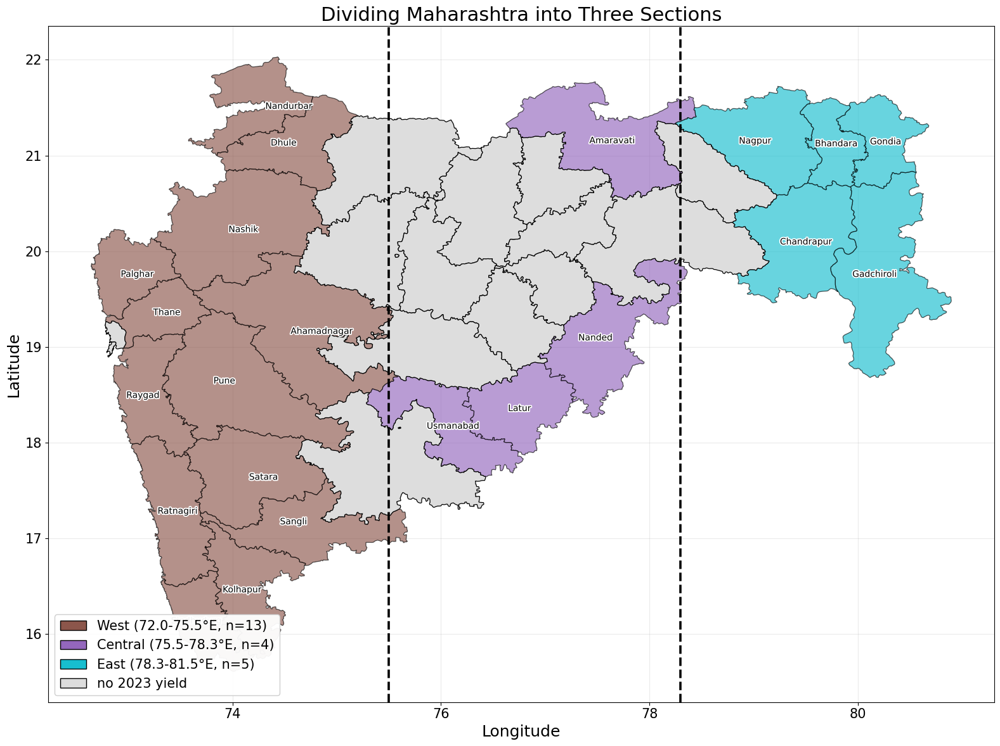

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


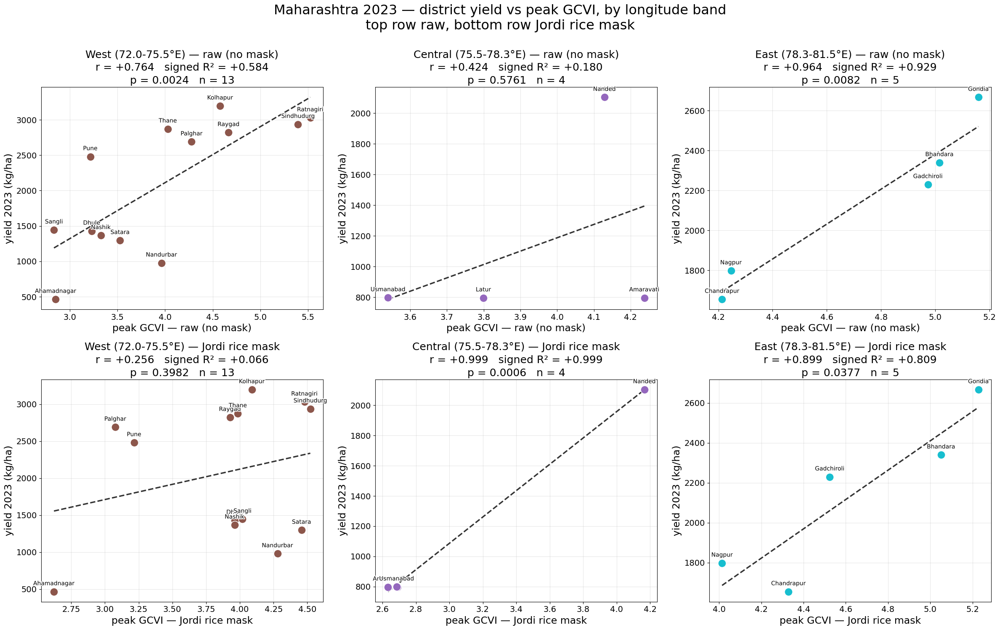

pooled correlation within each band, Maharashtra 2023

band        n    r_raw        p   r_jordi        p       dr   sR2_raw  sR2_jordi     dsR2    b_raw  b_jordi  rice_sh   yield
----------------------------------------------------------------------------------------------------------------------------
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
West       13   +0.764   0.0024    +0.256   0.3982   -0.508    +0.584     +0.066   -0.518      791      411    0.405    2077
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (

In [16]:
MH_KEY, MH_NAME = 'maharashtra', 'Maharashtra'
MH_BANDS = [('West', 72.0, 75.5), ('Central', 75.5, 78.3), ('East', 78.3, 81.5)]

MH, MH_G = state_bands(MH_KEY, MH_NAME, MH_BANDS)
MH.to_csv(f'{OUT}/maharashtra_bands_district_{YEAR}.csv', index=False)
for nm, lo, hi in MH_BANDS:
    s = MH[MH.band == nm].sort_values('lon')
    print(f"\n{nm} ({lo}-{hi}°E): n = {len(s)}")
    print('   ' + ', '.join(f"{r.district} ({r.lon:.1f})" for _, r in s.iterrows()))
print(f"\ntotal assigned {(MH.band != 'outside').sum()} of {len(MH)}"
      f"   ({len(MH_G)} boundary polygons, {len(MH_G) - len(MH)} without a {YEAR} yield)")

band_map(MH, MH_G, MH_BANDS, f'Dividing {MH_NAME} into Three Sections',
         f'{OUT}/maharashtra_bands_map.png')
band_scatters(MH, MH_BANDS, MH_NAME, f'{OUT}/maharashtra_bands_scatter_{YEAR}.png')
band_table(MH, MH_BANDS, MH_NAME)

print("\n\ntwo-band split (Central's 4 districts folded into the nearer side is not\n"
      "meaningful either, so Central is dropped): West < 75.5, East >= 78.3\n")
TWO = MH[MH.band != 'Central']
band_table(TWO, [('West', 72.0, 75.5), ('East', 78.3, 81.5)], f'{MH_NAME} (2 bands)')

## 7. Uttar Pradesh — the same section analysis

UP has 74 of 75 districts matched (Hamirpur is lost to the `Ham|Rpur` spelling in the
GAUL file — see the name-matching note in `RESULTS_SUMMARY.txt`), and its districts are
spread evenly across 77.3–84.1°E with **no gaps** to place cuts in. So the bands are
**longitude tertiles**: 79.1 and 81.8, giving 25 / 24 / 25.

That makes UP the one state here whose split is arbitrary rather than data-driven —
MP used round longitudes, Telangana the training-point gap, Maharashtra the gaps left
by districts without a rice yield.

Tables are printed in a separate cell from the figures: `nbconvert` drops a line when
stdout interleaves with `plt.show()` output, which silently lost a row in §5 and §6.

In [17]:
UP_KEY, UP_NAME = 'up', 'Uttar Pradesh'
UP_BANDS = [('West', 76.0, 79.1), ('Central', 79.1, 81.8), ('East', 81.8, 85.0)]

UP, UP_G = state_bands(UP_KEY, UP_NAME, UP_BANDS)
UP.to_csv(f'{OUT}/up_bands_district_{YEAR}.csv', index=False)
for nm, lo, hi in UP_BANDS:
    s = UP[UP.band == nm].sort_values('lon')
    print(f"\n{nm} ({lo}-{hi}°E): n = {len(s)}")
    print('   ' + ', '.join(f"{r.district} ({r.lon:.1f})" for _, r in s.iterrows()))
print(f"\ntotal assigned {(UP.band != 'outside').sum()} of {len(UP)}"
      f"   ({len(UP_G)} polygons, {len(UP_G) - len(UP)} unmatched)")


West (76.0-79.1°E): n = 25
   Shamli (77.3), Baghpat (77.3), Ghaziabad (77.5), Saharanpur (77.5), Mathura (77.6), Gautambudhnagar (77.6), Muzaffarnagar (77.7), Meerut (77.8), Hapur (77.9), Agra (77.9), Bulandshahr (78.0), Hathras (78.1), Aligarh (78.1), Amroha (78.3), Firozabad (78.5), Bijnor (78.5), Lalitpur (78.5), Sambhal (78.6), Etah (78.6), Jhansi (78.7), Moradabad (78.8), Kasganj (78.8), Budaun (79.0), Mainpuri (79.1), Etawah (79.1)

Central (79.1-81.8°E): n = 24
   Rampur (79.2), Jalaun (79.4), Bareilly (79.4), Farrukhabad (79.5), Auraiya (79.5), Kannauj (79.7), Mahoba (79.7), Shahjahanpur (79.7), Kanpur Dehat (79.9), Hardoi (80.1), Pilibhit (80.1), Kanpur (80.3), Banda (80.6), Unnao (80.6), Kheri (80.7), Sitapur (80.8), Fatehpur (80.9), Lucknow (80.9), Chitrakoot (81.1), Raibeareli (81.2), Barabanki (81.4), Kaushambi (81.4), Bahraich (81.5), Amethi (81.6)

East (81.8-85.0°E): n = 25
   Pratapgarh (81.8), Shrawasti (81.9), Prayagraj (81.9), Gonda (81.9), Ayodhya (82.1), Sultanp

In [18]:
band_table(UP, UP_BANDS, UP_NAME)

pooled correlation within each band, Uttar Pradesh 2023

band        n    r_raw        p   r_jordi        p       dr   sR2_raw  sR2_jordi     dsR2    b_raw  b_jordi  rice_sh   yield
----------------------------------------------------------------------------------------------------------------------------
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.West       25   -0.096   0.6465    +0.244   0.2407   +0.340    -0.009     +0.059   +0.069      -57      131    0.259    2629
Central    24   +0.117   0.5860    +0.167   0.4361   +0.050    +0.014

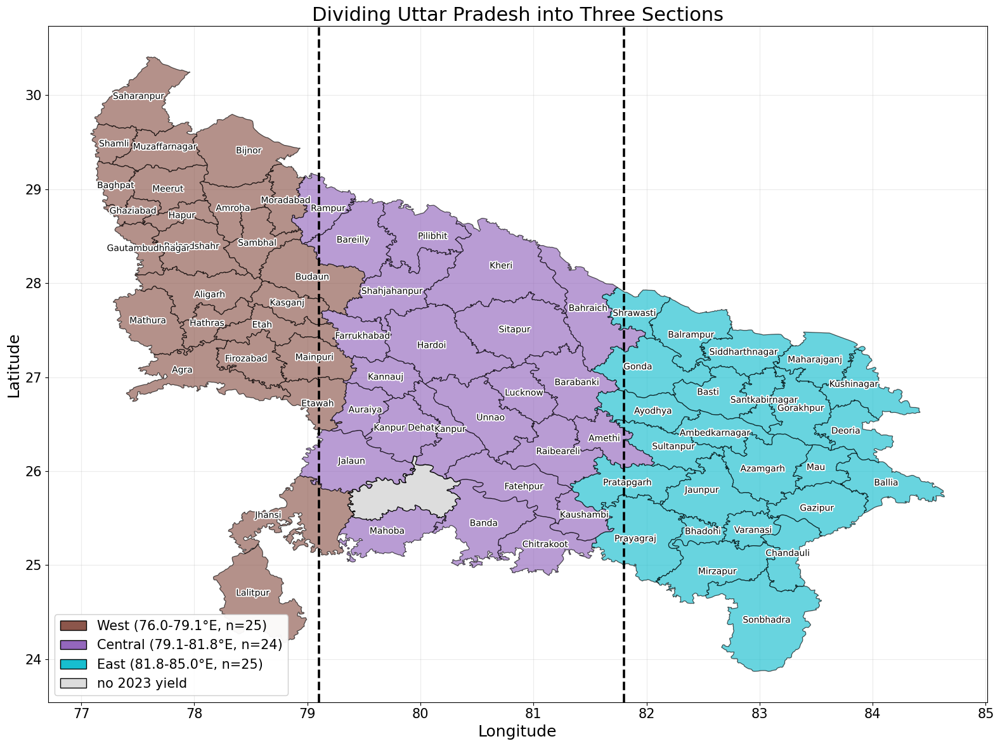

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


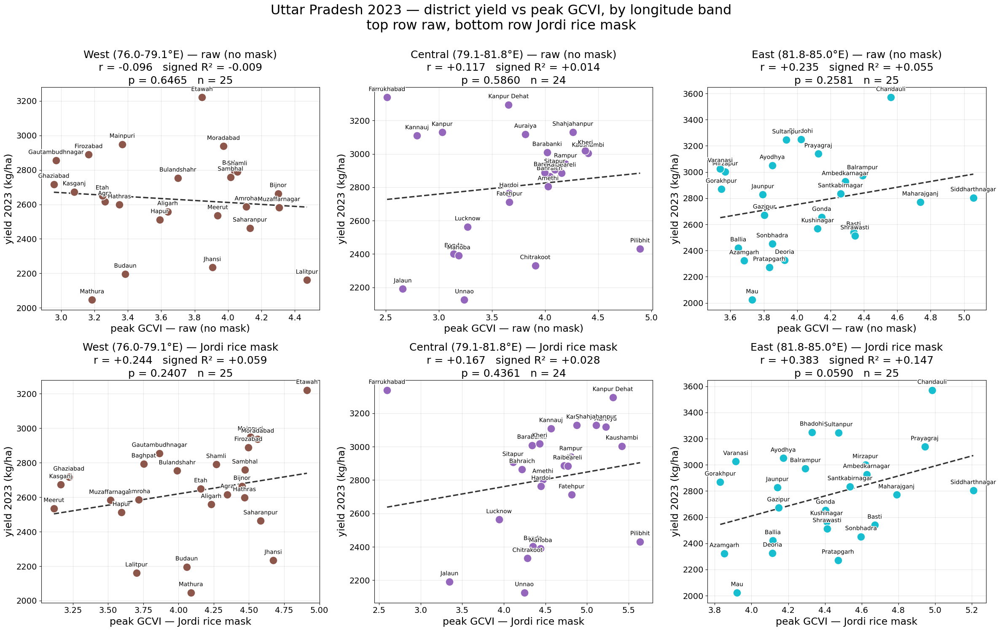

In [19]:
band_map(UP, UP_G, UP_BANDS, f'Dividing {UP_NAME} into Three Sections',
         f'{OUT}/up_bands_map.png')
band_scatters(UP, UP_BANDS, UP_NAME, f'{OUT}/up_bands_scatter_{YEAR}.png')

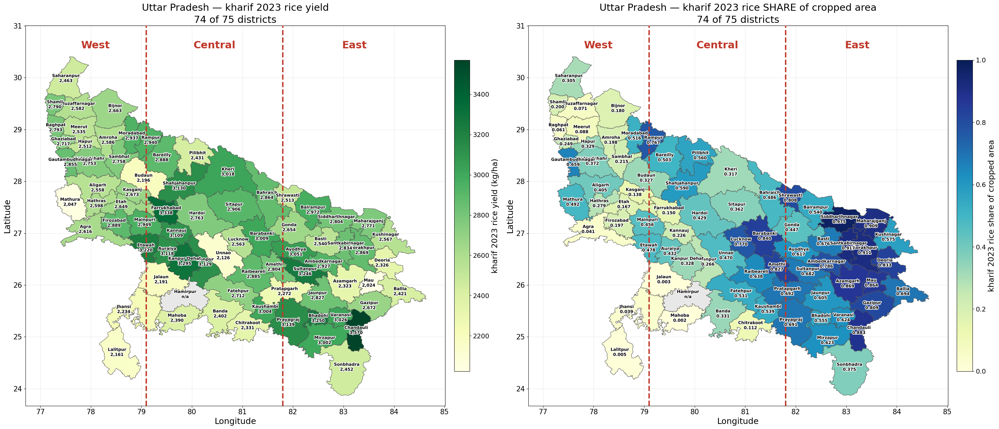

In [20]:
def yield_share_map(key, state_name, bands, outfile):
    """Two panels: kharif yield and census rice share, with the band cuts drawn in."""
    g = gpd.read_file(REGIONS[key]['shp']).to_crs('EPSG:4326')
    g = g[g.geometry.notna() & ~g.geometry.is_empty]
    g['district'] = g['gaul2_name'].str.strip().str.title().str.replace(r'\s+', ' ', regex=True)
    y = load_yield(state_name); y = y[y.year == YEAR][['district', 'yield_kg_ha']]
    gy = g.merge(y, on='district', how='left').merge(
         census_share(state_name, BASKET)[['district', 'rice_share']], on='district', how='left')
    spec = [('yield_kg_ha', 'YlGn',  None,   f'kharif {YEAR} rice yield (kg/ha)',
             f'{state_name} — kharif {YEAR} rice yield', '{:,.0f}'),
            ('rice_share',  'YlGnBu', (0, 1), f'kharif {YEAR} rice share of cropped area',
             f'{state_name} — kharif {YEAR} rice SHARE of cropped area', '{:.3f}')]
    fig, axes = plt.subplots(1, 2, figsize=(30, 13))
    for ax, (col, cmap, lim, cblab, title, fmt) in zip(axes, spec):
        have, miss = gy[gy[col].notna()], gy[gy[col].isna()]
        vmin, vmax = lim if lim else (have[col].min(), have[col].max())
        if len(miss):
            miss.plot(ax=ax, color='#e8e8e8', edgecolor='#888', linewidth=0.8, zorder=2)
        have.plot(column=col, ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
                  edgecolor='#555', linewidth=0.8, zorder=2)
        b = gy.total_bounds
        for _, _, hi in bands[:-1]:
            ax.axvline(hi, color='#c0392b', ls='--', lw=3.0, zorder=5)
        for nm, lo, hi in bands:
            ax.text((max(lo, b[0]) + min(hi, b[2])) / 2, b[3] + 0.12, nm, ha='center',
                    va='bottom', fontsize=22, fontweight='bold', color='#c0392b', zorder=6)
        for _, r in gy.iterrows():
            c = r.geometry.representative_point()
            lab = (f"{r['district']}\n{fmt.format(r[col])}" if np.isfinite(r[col])
                   else f"{r['district']}\nn/a")
            ax.annotate(lab, (c.x, c.y), fontsize=9, fontweight='bold', ha='center',
                        va='center', zorder=6, linespacing=1.2,
                        path_effects=[pe.withStroke(linewidth=2.8, foreground='white')])
        cb = fig.colorbar(ScalarMappable(norm=Normalize(vmin, vmax), cmap=cmap),
                          ax=ax, fraction=0.035, pad=0.02)
        cb.set_label(cblab, fontsize=17); cb.ax.tick_params(labelsize=14)
        ax.set_ylim(b[1] - 0.2, b[3] + 0.6)
        ax.set_xlabel('Longitude', fontsize=18); ax.set_ylabel('Latitude', fontsize=18)
        ax.tick_params(labelsize=15); ax.grid(alpha=0.25); ax.set_aspect('auto')
        ax.set_title(f'{title}\n{gy[col].notna().sum()} of {len(gy)} districts',
                     fontsize=21, linespacing=1.35)
    plt.tight_layout(); plt.savefig(outfile, dpi=140, bbox_inches='tight'); plt.show()
    return gy


from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
UP_GY = yield_share_map(UP_KEY, UP_NAME, UP_BANDS, f'{OUT}/up_yield_riceshare_{YEAR}.png')

In [21]:
print(f"{'band':<9}{'n':>4}{'share mean':>12}{'median':>9}{'min':>8}{'max':>8}{'yield mean':>12}")
print('-' * 62)
for nm, _, _ in UP_BANDS:
    s = UP[UP.band == nm]
    print(f"{nm:<9}{len(s):>4}{s.rice_share.mean():>12.3f}{s.rice_share.median():>9.3f}"
          f"{s.rice_share.min():>8.3f}{s.rice_share.max():>8.3f}{s.yield_kg_ha.mean():>12.0f}")
print(f"{'ALL':<9}{len(UP):>4}{UP.rice_share.mean():>12.3f}{UP.rice_share.median():>9.3f}"
      f"{UP.rice_share.min():>8.3f}{UP.rice_share.max():>8.3f}{UP.yield_kg_ha.mean():>12.0f}")
r_, p_ = stats.pearsonr(UP.rice_share, UP.yield_kg_ha)
print(f"\nr(rice share, yield) = {r_:+.3f}  p = {p_:.4f}  n = {len(UP)}")

band        n  share mean   median     min     max  yield mean
--------------------------------------------------------------
West       25       0.259    0.215   0.005   0.659        2629
Central    24       0.437    0.451   0.002   0.840        2806
East       25       0.718    0.692   0.375   0.975        2762
ALL        74       0.472    0.482   0.002   0.975        2732

r(rice share, yield) = +0.194  p = 0.0973  n = 74
